le resultat (pgcd, u, v) est : (2, -9, 47)
Test reussi!
Calcul des mesures en cours...
n =     1,000 | Base : 0.0002s | Opt : 0.0001s | Gain : 2.25x
n =    10,000 | Base : 0.0024s | Opt : 0.0007s | Gain : 3.50x
n =   100,000 | Base : 0.0198s | Opt : 0.0049s | Gain : 4.06x
n = 1,000,000 | Base : 0.1586s | Opt : 0.0519s | Gain : 3.05x


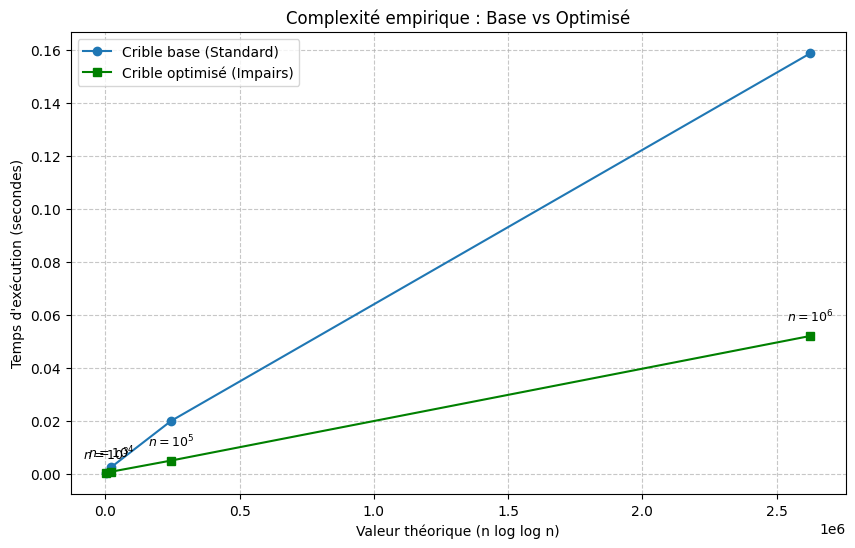


ANALYSE DES RÉSULTATS :
------------------------------
Le graphique montre une relation linéaire entre le temps et (n log log n).
On en conclut que l'algorithme respecte sa complexité asymptotique théorique.
L'optimisation des impairs réduit la constante de temps (la pente), doublant l'efficacité.


In [2]:
import timeit
import matplotlib.pyplot as plt
import numpy as np
import math

#%matplotlib inline

# PARTIE 1: VERSION RECURSIVE
def euclide_etendu_rec(a, b):
    """
    Algorithme d'Euclide étendu (version récursive).
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    # Condition d'arret : si b est nul, le PGCD est a
    if b == 0:
        return (a, 1, 0)
    else:
        #Appel recursif avec les nouveaux restes
        d, u1, v1 = euclide_etendu_rec(b, a % b)
        #Mise a jour des coefficients u et v
        u = v1
        v = u1 - (a // b) * v1
        return (d, u, v)
 # on appelle la fonction avec deux nombres , par exemple 120 et 35
resultat = euclide_etendu_rec(240, 46)
 # on affiche le resultat dans le terminal 
print("le resultat (pgcd, u, v) est :", resultat)

#PARTIE 2 : VERSION ITERATIVE
def euclide_etendu_iter(a, b):
    #Initialisation des variables (u, v pour a ) et (u' ,v' pour b)
    u, v, r = 1, 0, a
    u_prime, v_prime, r_prime =0, 1, b
    
    #Boucle tant que le reste n'est pas nul
    while r_prime != 0:
         q = r // r_prime #Quotient de la division

         #On decale les valeurs (r devient r_prime, r_prime devient le reste)
         r, r_prime = r_prime, r - q * r_prime
         u, u_prime = u_prime, u - q * u_prime
         v, v_prime = v_prime, v - q * v_prime
    return (r, u, v) 
#Test de la version iterative
d, u, v = euclide_etendu_iter(240, 46)
print("Test reussi!" if d==2 and 240*u + 46*v == 2 else "Erreur dans le calcul")

#PARTIE 3 et 4: CRIBLE D'ERATOSTHENE et ANALYSE DE complexiter empirique , COURBE
import math
import timeit
import matplotlib.pyplot as plt

# ==========================================
# 1. DÉFINITION DES DEUX FONCTIONS DE CRIBLE
# ==========================================

def eratosthene(n):
    """
    Version classique du crible d'Ératosthène.
    """
    if n < 2:
        return []
    crible = [True] * (n + 1)
    crible[0] = crible[1] = False
    for i in range(2, int(n**0.5) + 1):
        if crible[i]:
            for j in range(i * i, n + 1, i):
                crible[j] = False
    return [i for i, prime in enumerate(crible) if prime]


def eratosthene_opt(n):
    """
    Version optimisée : n'alloue de la mémoire et ne boucle que sur les impairs.
    """
    if n < 2:
        return []
    if n == 2:
        return [2]
    
    # Taille du tableau ne contenant que les impairs de 1 à n
    taille = (n + 1) // 2
    crible = [True] * taille
    crible[0] = False  # Le nombre 1 (indice 0) n'est pas premier
    
    limite = int(n**0.5)
    for i in range(1, taille):
        p = 2 * i + 1
        if p > limite:
            break
        if crible[i]:
            debut = (p * p - 1) // 2
            for j in range(debut, taille, p):
                crible[j] = False
                
    premiers = [2]
    for i in range(1, taille):
        if crible[i]:
            premiers.append(2 * i + 1)
            
    return premiers


# ==========================================
# 2. PROTOCOLE ET MESURES DE PERFORMANCES
# ==========================================

def mesurer_temps(fonction, n, repetitions=3):
    """
    Mesure le temps moyen d'exécution d'une fonction pour une taille n donnée.
    """
    timer = timeit.Timer(lambda: fonction(n))
    temps = timer.timeit(number=repetitions)
    return temps / repetitions


# Définition des valeurs de n : 10^3, 10^4, 10^5, 10^6, 10^7
# NOTE : On s'arrête ici à 10^6 par défaut pour que l'exécution reste rapide chez vous. 
# Si votre machine est puissante, vous pouvez changer l'intervalle à (3, 8).
valeurs_n = [10**i for i in range(3, 7)] 

temps_base = []
temps_opt = []

print("Calcul des mesures en cours...")
for n in valeurs_n:
    t_base = mesurer_temps(eratosthene, n, repetitions=3)
    t_opt = mesurer_temps(eratosthene_opt, n, repetitions=3)
    
    temps_base.append(t_base)
    temps_opt.append(t_opt)
    
    gain = t_base / t_opt if t_opt > 0 else 1
    print(f"n = {n:9,d} | Base : {t_base:.4f}s | Opt : {t_opt:.4f}s | Gain : {gain:.2f}x")


# ==========================================
# 3. TRACÉ DU GRAPHIQUE CORRIGÉ
# ==========================================

# Calcul de l'abscisse théorique : n * log(log(n))
n_loglog = [n * math.log(math.log(n)) if n > 2 else 0 for n in valeurs_n]

plt.figure(figsize=(10, 6))

# Tracé pour la version de base
plt.plot(n_loglog, temps_base, 'o-', label='Crible base (Standard)')

# Tracé pour la version optimisée (impairs uniquement)
plt.plot(n_loglog, temps_opt, 's-', label='Crible optimisé (Impairs)', color='green')

# Habillage du graphique
plt.xlabel('Valeur théorique (n log log n)')
plt.ylabel('Temps d\'exécution (secondes)')
plt.title('Complexité empirique : Base vs Optimisé')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Placement sécurisé des annotations au-dessus des points mesurés
for n, x_val, y_val in zip(valeurs_n, n_loglog, temps_opt):
    puissance = int(round(math.log10(n)))
    plt.annotate(
        f"$n=10^{puissance}$", 
        xy=(x_val, y_val), 
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center', 
        fontsize=9,
        fontweight='bold'
    )

plt.show()

#PARTIE5: CONCLUSION
print("\nANALYSE DES RÉSULTATS :")
print("-" * 30)
print("Le graphique montre une relation linéaire entre le temps et (n log log n).")
print("On en conclut que l'algorithme respecte sa complexité asymptotique théorique.")
print("L'optimisation des impairs réduit la constante de temps (la pente), doublant l'efficacité.")
